# Bengaluru House Price Prediction – Regression Model

This project builds a Machine Learning regression model to predict house prices in Bengaluru using property features such as location, square footage, number of bathrooms, and balcony count.

The project demonstrates a complete ML workflow including data cleaning, preprocessing, model training, and evaluation.

## Step 1 – Import Libraries

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Step 2 – Load Dataset

In [17]:
data = pd.read_csv("Bengaluru_House_Data.csv")

data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## Step 3 – Dataset Information

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


## Step 4 – Clean total_sqft

In [19]:
def convert_sqft(x):
    try:
        if '-' in x:
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data["total_sqft"] = data["total_sqft"].apply(convert_sqft)

## Step 5 – Handle Missing Values

In [20]:
data = data.dropna()

data.isnull().sum()

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

## Step 6 – Select Features and Target

In [21]:
# Select Features and Target

X = data[["total_sqft", "bath", "balcony"]]
y = data["price"]

X.head()

,total_sqft,bath,balcony
0,1056.0,2.0,1.0
1,2600.0,5.0,3.0
3,1521.0,3.0,1.0
5,1170.0,2.0,1.0
11,2785.0,5.0,3.0


## Step 7 – Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5984, 3)
Test set size: (1497, 3)


## Step 8 – Feature Scaling

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.18075915,  0.5943265 , -0.81315221],
       [-0.24424419, -0.52475776,  0.47208361],
       [-0.67951331, -1.64384201, -0.81315221],
       [-0.47933058, -0.52475776, -2.09838802],
       [ 1.99266952,  1.71341075,  0.47208361]])

## Step 9 – Train Linear Regression Model

In [24]:
# Step 9 – Train Linear Regression Model

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Step 10 – Predictions

In [25]:
y_pred = model.predict(X_test_scaled)

y_pred[:10]

array([130.60364723,  52.86609568, 132.15382318, 147.57644562,
        57.87853029,  69.73963793,  59.13093784,  65.37236817,
       128.86666494,  56.34006026])

## Step 11 – Model Evaluation

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 31.112811893498957
MSE: 6655.538079753061
R2 Score: 0.4731089985566097


## Step 12 – Model Interpretation

In [27]:
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=["Coefficient"]
)

coefficients

,Coefficient
total_sqft,48.343194
bath,34.154627
balcony,-1.110697


## Step 13 – Actual vs Predicted Visualization

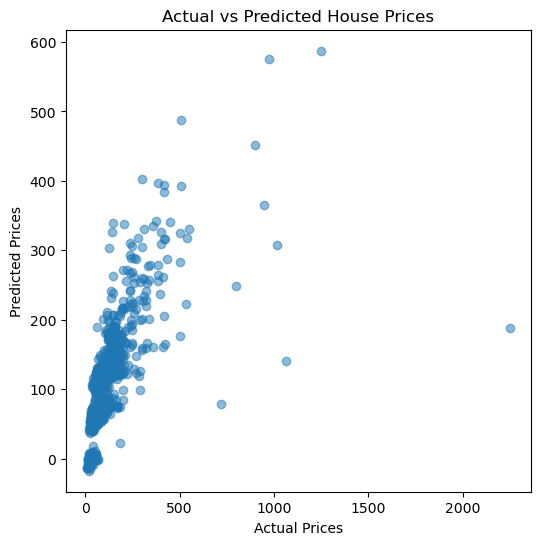

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()


## Step 14 – Prediction Example

In [29]:
sample_house = pd.DataFrame(
    [[1200, 2, 1]],
    columns=["total_sqft", "bath", "balcony"]
)

sample_scaled = scaler.transform(sample_house)

predicted_price = model.predict(sample_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 64.28055073030633


## Conclusion

The Linear Regression model predicts Bangalore house prices based on selected property features.

Model evaluation metrics such as MAE, MSE, and R² help measure the model's performance.